# OBJECT DETECTION PIPELINE — YOLOv8 + COCO + Gradio
##Google Colab Free Tier Compatible

## STEP 0 — SETUP ENVIRONMENT


In [2]:
!pip install ultralytics opencv-python-headless Pillow matplotlib gradio numpy pandas tqdm --q

In [3]:
# 0.2 Imports

import os
import time
import json
import warnings
import requests
import numpy as np
import pandas as pd
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from io import BytesIO
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
from ultralytics import YOLO
import gradio as gr

warnings.filterwarnings("ignore")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# 0.3 Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device.upper()}")

Device: CPU


#


In [5]:
# 0.4 Create folder structure
for folder in ["inputs", "outputs", "models", "batch_outputs"]:
    Path(folder).mkdir(exist_ok=True)
print("Folders ready: inputs/, outputs/, models/, batch_outputs/")

Folders ready: inputs/, outputs/, models/, batch_outputs/


## STEP 1 — CONFIG BLOCK


In [6]:
# 1.1 Model config
MODEL_SIZE = "yolov8n" # options: yolov8n (fast) | yolov8m (balanced)
WEIGHTS_PATH = f"models/{MODEL_SIZE}.pt"

In [9]:
# 1.2 Detection thresholds
CONF_THRESHOLD = 0.40
IOU_THRESHOLD = 0.45

In [10]:
# 1.3 Path configs
INPUT_FOLDER = "inputs"
OUTPUT_FOLDER = "outputs"
BATCH_OUT_FOLDER = "batch_outputs"

In [11]:
# 1.4 Display config
SHOW_CONFIDENCE = True
FONT_SCALE = 0.55
BOX_THICKNESS = 2

In [12]:
# 1.5 COCO class list (80 classes, index = class id)
COCO_CLASSES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train",
    "truck", "boat", "traffic light", "fire hydrant", "stop sign",
    "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag",
    "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite",
    "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana",
    "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza",
    "donut", "cake", "chair", "couch", "potted plant", "bed", "dining table",
    "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock",
    "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

In [13]:
# 1.6 Class filter (empty list = detect all 80 classes)
CLASS_FILTER = [] # e.g. ["person", "car", "dog"] to detect only those


In [14]:
# 1.7 Max detections per image
MAX_DETECTIONS = 50


In [15]:
# 1.8 Video config
FRAME_SKIP = 2 # process every Nth frame (1 = every frame)
VIDEO_FPS = 20

In [16]:
# Assign a consistent BGR color to each class (used in drawing)
np.random.seed(42)
CLASS_COLORS = {cls: tuple(int(x) for x in np.random.randint(50, 230, 3)) for cls in COCO_CLASSES}

In [17]:
CLASS_COLORS

{'person': (152, 229, 142),
 'bicycle': (64, 156, 121),
 'car': (70, 152, 171),
 'motorcycle': (124, 137, 166),
 'airplane': (149, 153, 201),
 'bus': (180, 199, 102),
 'train': (51, 137, 207),
 'truck': (87, 179, 70),
 'boat': (210, 107, 71),
 'traffic light': (138, 98, 108),
 'fire hydrant': (219, 64, 224),
 'stop sign': (100, 157, 104),
 'parking meter': (113, 180, 100),
 'bench': (184, 70, 122),
 'bird': (216, 67, 181),
 'cat': (138, 109, 63),
 'dog': (58, 139, 102),
 'horse': (179, 133, 141),
 'sheep': (160, 221, 57),
 'cow': (224, 84, 130),
 'elephant': (213, 99, 153),
 'bear': (181, 51, 183),
 'zebra': (103, 155, 53),
 'giraffe': (103, 195, 93),
 'backpack': (211, 63, 144),
 'umbrella': (97, 64, 89),
 'handbag': (131, 160, 102),
 'tie': (73, 203, 173),
 'suitcase': (90, 206, 64),
 'frisbee': (94, 114, 138),
 'skis': (120, 58, 137),
 'snowboard': (178, 185, 112),
 'sports ball': (188, 130, 185),
 'kite': (212, 212, 82),
 'baseball bat': (172, 54, 90),
 'baseball glove': (77, 184, 

## STEP 2 — LOAD PRETRAINED MODEL


In [18]:
def load_model(model_size=MODEL_SIZE):
    """Load YOLOv8 pretrained weights. Auto-downloads if not cached."""
    weights = f"models/{model_size}.pt"

    # 2.1 Load model (downloads automatically on first run)
    t0 = time.time()
    model = YOLO(weights)
    load_time = round(time.time() - t0, 2)

    # 2.2 Basic model info
    print(f"Model: {model_size}")
    print(f"Loaded: {load_time}s  |  Device: {device.upper()}")

    # 2.3 Verify class list
    model_classes = list(model.names.values())
    assert len(model_classes) == 80, "Expected 80 COCO classes"
    print(f"Classes: {len(model_classes)} COCO classes confirmed")

    # 2.4 Sanity check — dummy white image 640x640
    dummy = np.ones((640, 640, 3), dtype=np.uint8) * 255
    result = model.predict(dummy, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD, verbose=False)
    print(f"Sanity: inference OK — {len(result[0].boxes)} detections on blank image")

    # 2.5 Already logged load time above
    return model


In [19]:
model = load_model(MODEL_SIZE)

Model   : yolov8n
Loaded  : 0.49s  |  Device: CPU
Classes : 80 COCO classes confirmed
Sanity  : inference OK — 0 detections on blank image


## STEP 3 — INPUT HANDLING + VALIDATION


In [22]:
SUPPORTED_FORMATS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
MAX_DIMENSION = 1920 # auto-resize if image exceeds this

In [21]:
def load_image_from_url(url):
    """Fetch image from URL. Returns PIL Image or None on failure."""
    try:
        resp = requests.get(url, timeout=10)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception as e:
        print(f"[URL ERROR] {e}")
        return None

In [23]:

def validate_and_load(image_input):
    """
    3.1–3.8: Accept file path or URL, validate, load, resize if needed.
    Returns: (np.ndarray BGR image, metadata dict) or (None, error_str)
    """
    img_pil = None

    # 3.1 Detect input type
    if isinstance(image_input, str) and image_input.startswith("http"):
        # 3.6 URL path
        img_pil = load_image_from_url(image_input)
        if img_pil is None:
            return None, "Could not fetch image from URL. Check the link and try again."
        source_name = image_input.split("/")[-1] or "url_image"

    elif isinstance(image_input, str):
        # 3.4 Check format
        ext = Path(image_input).suffix.lower()
        if ext not in SUPPORTED_FORMATS:
            return None, f"Unsupported format '{ext}'. Use: {', '.join(SUPPORTED_FORMATS)}"

        # 3.5 Try loading
        try:
            img_pil = Image.open(image_input).convert("RGB")
        except Exception:
            return None, "Could not read image. File may be corrupt or missing."
        source_name = Path(image_input).name

    elif isinstance(image_input, np.ndarray):
        # Already a numpy array (from Gradio)
        img_pil = Image.fromarray(image_input)
        source_name = "uploaded_image"

    elif isinstance(image_input, Image.Image):
        img_pil = image_input.convert("RGB")
        source_name = "pil_image"

    else:
        return None, "Unsupported input type. Pass a file path, URL, or image array."

    # 3.3 Basic validation
    if img_pil is None:
        return None, "Image could not be loaded."

    w, h = img_pil.size
    if w < 10 or h < 10:
        return None, f"Image too small ({w}x{h}). Minimum 10x10 pixels."

    # 3.7 Auto-resize if too large
    if max(w, h) > MAX_DIMENSION:
        scale = MAX_DIMENSION / max(w, h)
        new_w, new_h = int(w * scale), int(h * scale)
        img_pil = img_pil.resize((new_w, new_h), Image.LANCZOS)
        print(f"[RESIZE] {w}x{h} → {new_w}x{new_h} (exceeded {MAX_DIMENSION}px limit)")
        w, h = new_w, new_h

    # Convert to BGR numpy for OpenCV
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

    # 3.8 Metadata
    meta = {
        "filename" : source_name,
        "width" : w,
        "height" : h,
        "channels" : img_bgr.shape[2],
        "size_kb" : round(img_bgr.nbytes / 1024, 1)
    }
    print(f"[IMAGE] {meta['filename']} | {w}x{h} | {meta['size_kb']} KB")
    return img_bgr, meta

## STEP 4 — RUN DETECTION (INFERENCE)


In [24]:
def run_inference(img_bgr, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
                  class_filter=CLASS_FILTER, max_det=MAX_DETECTIONS):
    """
    4.1–4.7: Run YOLOv8 on image, extract and filter detections.
    Returns: (detections list, inference_time_ms float)
    Each detection: {"class": str, "confidence": float, "bbox": [x1,y1,x2,y2]}
    """
    # 4.1–4.2 Predict + time it
    t0 = time.time()
    results = model.predict(img_bgr, conf=conf, iou=iou, verbose=False)
    infer_ms = round((time.time() - t0) * 1000, 1)

    # 4.3 Extract raw boxes
    boxes = results[0].boxes
    raw_det = []
    for box in boxes:
        cls_id     = int(box.cls[0])
        class_name = COCO_CLASSES[cls_id] if cls_id < len(COCO_CLASSES) else f"class_{cls_id}"
        confidence = round(float(box.conf[0]), 3)
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]

        # 4.4 Class name already mapped above
        # 4.5 Apply class filter
        if class_filter and class_name not in class_filter:
            continue

        raw_det.append({"class": class_name, "confidence": confidence,
                         "bbox": [x1, y1, x2, y2]})

    # 4.6 Sort by confidence, then cap
    raw_det.sort(key=lambda x: x["confidence"], reverse=True)
    detections = raw_det[:max_det]

    # 4.7 Log to console
    print(f"[INFER] {infer_ms}ms | {len(detections)} detections")
    for d in detections:
        print(f"  {d['class']:20s}  {d['confidence']*100:.1f}%  bbox={d['bbox']}")

    return detections, infer_ms


## STEP 5 — POST-PROCESSING


In [25]:
def postprocess(detections):
    """
    5.1–5.5: Validate detections, compute summary stats.
    Returns: (clean detections list, summary dict)
    """
    # 5.1 NMS is applied internally by YOLO — no duplicates expected
    # 5.2 Already structured dicts from Step 4
    # 5.3 Already sorted by confidence in Step 4

    # 5.4 Count stats
    total = len(detections)
    unique = list(set(d["class"] for d in detections))

    # 5.5 Zero-detection case
    if total == 0:
        print("[WARN] No objects detected in this image.")
        return detections, {"total": 0, "unique_classes": [], "message": "No objects detected."}

    summary = {
        "total" : total,
        "unique_classes" : unique,
        "class_counts" : {cls: sum(1 for d in detections if d["class"] == cls) for cls in unique},
        "message" : f"{total} object(s) found across {len(unique)} class(es)."
    }
    print(f"[POST] {summary['message']}")
    return detections, summary


## STEP 6 — VISUALIZATION (DRAW ON IMAGE)


In [27]:
def get_text_color(bg_color):
    """Return black or white text based on background brightness."""
    b, g, r = bg_color
    brightness = 0.299 * r + 0.587 * g + 0.114 * b
    return (0, 0, 0) if brightness > 127 else (255, 255, 255)

In [28]:
def draw_detections(img_bgr, detections, show_conf=SHOW_CONFIDENCE):
    """
    6.1–6.5: Draw boxes, labels, confidence on image copy.
    Returns: annotated BGR image (np.ndarray)
    """
    img_out = img_bgr.copy()
    h_img, w_img = img_out.shape[:2]

    for det in detections:
        cls = det["class"]
        conf = det["confidence"]
        x1, y1, x2, y2 = det["bbox"]
        color = CLASS_COLORS.get(cls, (0, 200, 0))

        # 6.1 Draw box
        cv2.rectangle(img_out, (x1, y1), (x2, y2), color, BOX_THICKNESS)

        # 6.2–6.3 Build label
        label = f"{cls} {conf*100:.0f}%" if show_conf else cls

        # Measure text size for background rect
        (tw, th), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, 1)

        # 6.5 Clamp label position so it stays in frame
        lx = x1
        ly = max(y1 - th - baseline - 4, th + baseline + 4)

        # 6.4 Draw filled label background for readability
        cv2.rectangle(img_out, (lx, ly - th - baseline - 2), (lx + tw + 4, ly), color, -1)
        text_color = get_text_color(color)
        cv2.putText(img_out, label, (lx + 2, ly - baseline - 1),
                    cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, text_color, 1, cv2.LINE_AA)

    return img_out


In [29]:
def show_comparison(original_bgr, annotated_bgr):
    """6.6 Side-by-side original vs annotated (for notebook display)."""
    orig_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    ann_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(orig_rgb);  axes[0].set_title("Original");   axes[0].axis("off")
    axes[1].imshow(ann_rgb);   axes[1].set_title("Detected");   axes[1].axis("off")
    plt.tight_layout()
    plt.show()

## STEP 7 — DETECTION RESULTS SUMMARY


In [30]:
def print_summary(detections, summary, infer_ms):
    """7.1–7.5: Print detection summary to console in readable table format."""

    print("\n" + "="*55)
    print(f"DETECTION SUMMARY")
    print("="*55)

    # 7.1 Total count
    print(f"  Total objects   : {summary['total']}")

    # 7.5 Inference time
    print(f"  Inference time  : {infer_ms} ms")

    if summary["total"] == 0:
        print("  No detections found.")
        print("="*55 + "\n")
        return

    # 7.4 Average confidence
    avg_conf = np.mean([d["confidence"] for d in detections]) * 100
    print(f"  Avg confidence  : {avg_conf:.1f}%")

    # 7.2 Class-wise table
    print("\n Class Breakdown:")
    print(f"{'Class':<20} {'Count':>5} {'Avg Conf':>10} {'Max Conf':>10}")
    print("  " + "-"*48)

    for cls in summary["unique_classes"]:
        cls_dets = [d for d in detections if d["class"] == cls]
        count = len(cls_dets)
        avg_c = np.mean([d["confidence"] for d in cls_dets]) * 100
        max_c = max(d["confidence"] for d in cls_dets) * 100
        print(f"{cls:<20} {count:>5} {avg_c:>9.1f}% {max_c:>9.1f}%")

    # 7.3 Top-5 detections
    print("\n  Top-5 Detections:")
    for i, d in enumerate(detections[:5], 1):
        print(f"{i}. {d['class']:20s}  {d['confidence']*100:.1f}%")

    print("="*55 + "\n")


In [31]:
def build_summary_df(detections, summary):
    """Build a pandas DataFrame of the class breakdown (used by Step 8 CSV)."""
    rows = []
    for cls in summary.get("unique_classes", []):
        cls_dets = [d for d in detections if d["class"] == cls]
        rows.append({
            "class": cls,
            "count": len(cls_dets),
            "avg_conf": round(np.mean([d["confidence"] for d in cls_dets]), 3),
            "max_conf": round(max(d["confidence"] for d in cls_dets), 3)
        })
    return pd.DataFrame(rows).sort_values("count", ascending=False).reset_index(drop=True)

## STEP 8 — SAVE OUTPUTS


In [32]:
def make_timestamp():
    """Return compact timestamp string for filenames."""
    return datetime.now().strftime("%Y%m%d_%H%M%S")

In [33]:
def save_outputs(annotated_bgr, detections, summary, infer_ms, source_name,
                 out_folder=OUTPUT_FOLDER):
    """
    8.1–8.5: Save annotated image, JSON results, and CSV summary.
    Returns: dict of saved file paths.
    """
    ts = make_timestamp()
    stem = Path(source_name).stem
    base = f"{stem}_{ts}"
    paths = {}

    # 8.1–8.2 Save annotated image
    img_path = os.path.join(out_folder, f"{base}.jpg")
    cv2.imwrite(img_path, annotated_bgr)
    paths["image"] = img_path

    # 8.3 Save JSON
    json_data = {
        "image_name": source_name,
        "timestamp": ts,
        "total_count": summary["total"],
        "inference_time_ms": infer_ms,
        "detections": detections
    }
    json_path = os.path.join(out_folder, f"{base}.json")
    with open(json_path, "w") as f:
        json.dump(json_data, f, indent=2)
    paths["json"] = json_path

    # 8.4 Save CSV summary
    df = build_summary_df(detections, summary)
    csv_path = os.path.join(out_folder, f"{base}_summary.csv")
    df.to_csv(csv_path, index=False)
    paths["csv"] = csv_path

    # 8.5 Log paths
    print("[SAVED]")
    for k, v in paths.items():
        print(f"  {k:6s} → {v}")

    return paths


## STEP 9 — BATCH IMAGE PROCESSING


In [34]:
def run_batch(folder_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
              class_filter=CLASS_FILTER):
    """
    Process all valid images in a folder.
    Returns: batch_summary dict
    """
    # 9.1 Collect image files
    all_files = list(Path(folder_path).iterdir())
    img_files = [f for f in all_files if f.suffix.lower() in SUPPORTED_FORMATS]

    if not img_files:
        print(f"[BATCH] No supported images found in '{folder_path}'")
        return {}

    print(f"[BATCH] Found {len(img_files)} images in '{folder_path}'")

    all_detections = [] # every detection across the batch
    processed_count = 0
    skipped_count = 0

    # 9.3–9.4 Loop with progress bar
    for img_path in tqdm(img_files, desc="Batch Processing"):

        # 9.2 Validate each image
        img_bgr, result = validate_and_load(str(img_path))
        if img_bgr is None:
            print(f"  [SKIP] {img_path.name} — {result}")
            skipped_count += 1
            continue

        # Run full pipeline per image (Steps 4→5→6)
        detections, infer_ms = run_inference(img_bgr, conf, iou, class_filter)
        detections, summary = postprocess(detections)
        annotated = draw_detections(img_bgr, detections)

        # 9.5 Save annotated image to batch_outputs/
        out_path = os.path.join(BATCH_OUT_FOLDER, f"{img_path.stem}_detected.jpg")
        cv2.imwrite(out_path, annotated)

        # 9.6 Save individual JSON
        json_data = {
            "image_name": img_path.name,
            "timestamp": make_timestamp(),
            "total_count": summary["total"],
            "inference_time_ms": infer_ms,
            "detections": detections
        }
        json_path = os.path.join(BATCH_OUT_FOLDER, f"{img_path.stem}.json")
        with open(json_path, "w") as f:
            json.dump(json_data, f, indent=2)

        all_detections.extend(detections)
        processed_count += 1

    # 9.7 Combined batch summary
    total_objects = len(all_detections)
    class_counts = {}
    for d in all_detections:
        class_counts[d["class"]] = class_counts.get(d["class"], 0) + 1

    avg_conf_all = round(np.mean([d["confidence"] for d in all_detections]) * 100, 1) \
                   if all_detections else 0.0

    batch_summary = {
        "images_processed" : processed_count,
        "images_skipped" : skipped_count,
        "total_objects" : total_objects,
        "avg_confidence" : avg_conf_all,
        "class_breakdown" : class_counts
    }

    print("\n[BATCH SUMMARY]")
    print(f"Processed: {processed_count}  |  Skipped: {skipped_count}")
    print(f"Total objects found: {total_objects}")
    print(f"Avg confidence: {avg_conf_all}%")
    print(f"Classes detected: {len(class_counts)}")

    # 9.8 Export combined CSV
    ts = make_timestamp()
    df = pd.DataFrame([{"class": k, "count": v} for k, v in class_counts.items()])
    df = df.sort_values("count", ascending=False).reset_index(drop=True)
    csv_path = os.path.join(BATCH_OUT_FOLDER, f"batch_summary_{ts}.csv")
    df.to_csv(csv_path, index=False)
    print(f"  Batch CSV → {csv_path}")

    return batch_summary


## STEP 10 — VIDEO DETECTION


In [35]:
def run_video_detection(video_path, conf=CONF_THRESHOLD, iou=IOU_THRESHOLD,
                        class_filter=CLASS_FILTER):
    """
    10.1–10.7: Process video file frame by frame and save annotated output.
    Returns: output video path or None on failure.
    """
    # 10.1 Validate input file
    if not os.path.exists(video_path):
        print(f"[VIDEO ERROR] File not found: {video_path}")
        return None

    # 10.2 Open video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("[VIDEO ERROR] Cannot open video file.")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    orig_fps = cap.get(cv2.CAP_PROP_FPS) or VIDEO_FPS
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"[VIDEO] {Path(video_path).name} | {width}x{height} | {total_frames} frames | {orig_fps:.1f} FPS")

    # Setup output writer
    ts = make_timestamp()
    out_name = os.path.join(OUTPUT_FOLDER, f"{Path(video_path).stem}_detected_{ts}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_name, fourcc, VIDEO_FPS, (width, height))

    frame_idx = 0
    processed = 0
    last_annotated = None   # hold last annotated frame for skipped frames

    # 10.2–10.6 Frame loop
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # 10.3 Frame skip
        if frame_idx % FRAME_SKIP == 0:
            detections, _ = run_inference(frame, conf, iou, class_filter)
            detections, _ = postprocess(detections)
            last_annotated  = draw_detections(frame, detections)
            processed      += 1
        else:
            # Write last annotated frame to keep video smooth
            last_annotated = frame if last_annotated is None else last_annotated

        # 10.5 Write frame
        writer.write(last_annotated if last_annotated is not None else frame)

        # 10.6 Progress every 30 frames
        if frame_idx % 30 == 0:
            pct = round(frame_idx / max(total_frames, 1) * 100, 1)
            print(f"Frame {frame_idx}/{total_frames} ({pct}%)", end="\r")

        frame_idx += 1

    cap.release()
    writer.release()

    # 10.7 Log output
    print(f"\n[VIDEO] Done — {processed} frames processed")
    print(f"[VIDEO] Saved = {out_name}")
    return out_name


## STEP 11 — SINGLE IMAGE PREDICTION FUNCTION


In [36]:
def detect_objects(image_input, conf_threshold=CONF_THRESHOLD,
                   class_filter=CLASS_FILTER, model_size=MODEL_SIZE):
    """
    11.1–11.3: End-to-end single image detection pipeline.
    Accepts: file path | URL str | np.ndarray | PIL.Image
    Returns: (annotated_rgb, summary_dict, infer_ms) or (None, error_str, 0)
    """
    global model, MODEL_SIZE

    # Reload model if size changed
    if model_size != MODEL_SIZE:
        MODEL_SIZE = model_size
        model = load_model(model_size)

    # 11.2 Run pipeline steps 3→4→5→6
    img_bgr, result = validate_and_load(image_input)
    if img_bgr is None:
        return None, result, 0  # result is the error string here

    detections, infer_ms = run_inference(img_bgr, conf_threshold, IOU_THRESHOLD, class_filter)
    detections, summary = postprocess(detections)
    annotated_bgr = draw_detections(img_bgr, detections)

    # Also save outputs automatically
    source_name = summary.get("filename", "image") if isinstance(result, dict) else "image"
    meta = result if isinstance(result, dict) else {}
    save_outputs(annotated_bgr, detections, summary, infer_ms,
                 meta.get("filename", "image"))

    # 11.3 Return RGB for Gradio/matplotlib display
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    return annotated_rgb, summary, infer_ms


In [37]:
def test_pipeline():
    """11.4–11.5: Quick test using a public sample image."""
    test_url = "https://ultralytics.com/images/bus.jpg"
    print("\n[TEST] Running pipeline on sample image...")
    img, summary, ms = detect_objects(test_url)
    if img is None:
        print(f"[TEST FAILED] {summary}")
    else:
        print(f"[TEST PASSED] {summary['total']} objects | {ms}ms")
        show_comparison(
            cv2.cvtColor(np.array(Image.open(BytesIO(requests.get(test_url).content))), cv2.COLOR_RGB2BGR),
            cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        )


[TEST] Running pipeline on sample image...
[IMAGE] bus.jpg | 810x1080 | 2562.9 KB
[INFER] 335.4ms | 4 detections
  bus                   87.3%  bbox=[22, 231, 805, 756]
  person                86.6%  bbox=[48, 398, 245, 902]
  person                85.3%  bbox=[669, 392, 809, 877]
  person                82.5%  bbox=[221, 405, 344, 857]
[POST] 4 object(s) found across 2 class(es).
[SAVED]
  image  → outputs/bus_20260327_143327.jpg
  json   → outputs/bus_20260327_143327.json
  csv    → outputs/bus_20260327_143327_summary.csv
[TEST PASSED] 4 objects | 335.4ms


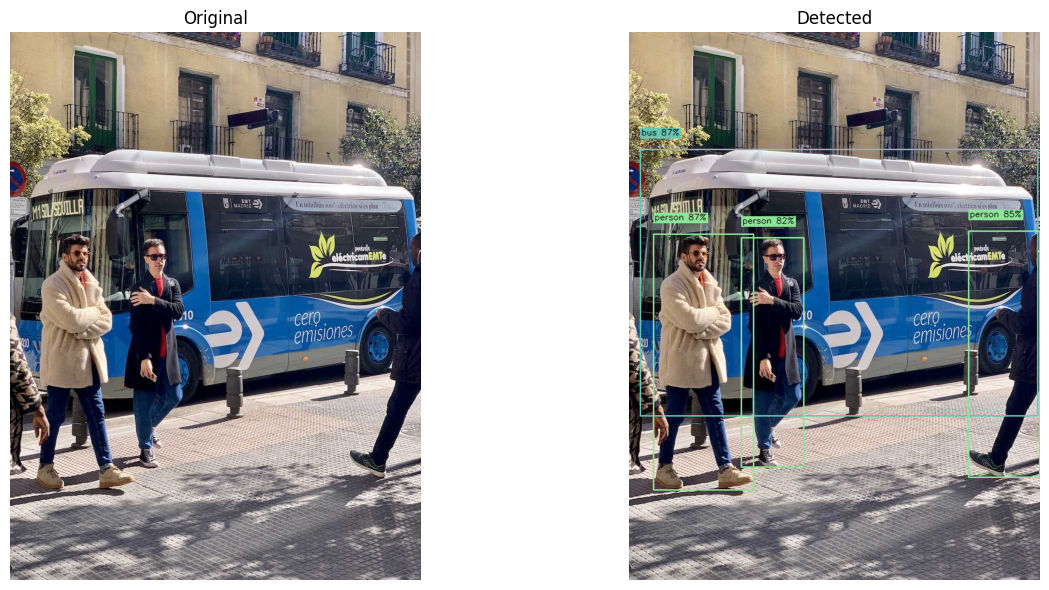

In [38]:
test_pipeline()


## STEP 12 — GRADIO WEB UI


In [39]:
def gradio_image_detect(image, conf_threshold, selected_classes, model_choice):
    """Gradio wrapper for image detection. Returns (annotated image, summary text, json path, img path)."""
    if image is None:
        return None, "Please upload an image.", None, None

    class_filter = selected_classes if selected_classes else []

    annotated_rgb, summary, infer_ms = detect_objects(
        image, conf_threshold, class_filter, model_choice
    )

    if annotated_rgb is None:
        return None, f"Error: {summary}", None, None

    # Build summary text for display panel
    lines = [f"Objects found: {summary['total']}",
             f"Inference time: {infer_ms} ms"]

    if summary["total"] > 0:
        avg_conf = np.mean([d["confidence"] for d in
                            [{"confidence": 0}]]) * 100  # placeholder fallback
        lines.append(f"\nClass Breakdown:")
        for cls, cnt in summary.get("class_counts", {}).items():
            lines.append(f"{cls}: {cnt}")

    summary_text = "\n".join(lines)

    # Find the last saved json/image for download
    saved_files = sorted(Path(OUTPUT_FOLDER).glob("*.json"), key=os.path.getmtime, reverse=True)
    json_dl = str(saved_files[0]) if saved_files else None

    saved_imgs = sorted(Path(OUTPUT_FOLDER).glob("*.jpg"), key=os.path.getmtime, reverse=True)
    img_dl = str(saved_imgs[0]) if saved_imgs else None

    return annotated_rgb, summary_text, json_dl, img_dl


In [40]:
def gradio_video_detect(video, conf_threshold, selected_classes, model_choice):
    """Gradio wrapper for video detection. Returns output video path."""
    if video is None:
        return None, "Please upload a video file."

    class_filter = selected_classes if selected_classes else []

    # Reload model if needed
    global model, MODEL_SIZE
    if model_choice != MODEL_SIZE:
        MODEL_SIZE = model_choice
        model = load_model(model_choice)

    out_path = run_video_detection(video, conf_threshold, IOU_THRESHOLD, class_filter)
    if out_path is None:
        return None, "Video processing failed. Check the file format."

    return out_path, f"Video saved to: {out_path}"


In [41]:
def build_summary_text(detections, summary, infer_ms):
    """Helper to build clean summary string for Gradio textbox."""
    if summary["total"] == 0:
        return f"No objects detected.\nInference time: {infer_ms} ms"

    lines = [
        f"Objects found : {summary['total']}",
        f"Inference time : {infer_ms} ms",
        f"Classes found : {len(summary['unique_classes'])}",
        "",
        "Top 5 Detections:"
    ]
    # We rebuild from summary since we dont carry detections into this helper
    for cls, cnt in list(summary.get("class_counts", {}).items())[:5]:
        lines.append(f"  {cls}: {cnt} detected")
    return "\n".join(lines)


In [42]:
def gradio_image_detect_v2(image, conf_threshold, selected_classes, model_choice):
    """Cleaner Gradio image wrapper that carries detections through properly."""
    if image is None:
        return None, "Upload an image to get started.", None, None

    class_filter = selected_classes if selected_classes else []

    global model, MODEL_SIZE
    if model_choice != MODEL_SIZE:
        MODEL_SIZE = model_choice
        model = load_model(model_choice)

    # Step 3→4→5→6 inline so we have detections for summary text
    img_bgr, meta = validate_and_load(image)
    if img_bgr is None:
        return None, f"Error: {meta}", None, None

    detections, infer_ms = run_inference(img_bgr, conf_threshold, IOU_THRESHOLD, class_filter)
    detections, summary = postprocess(detections)
    annotated_bgr = draw_detections(img_bgr, detections)
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

    saved = save_outputs(annotated_bgr, detections, summary, infer_ms,
                         meta.get("filename", "upload"))

    summary_text = build_summary_text(detections, summary, infer_ms)

    return annotated_rgb, summary_text, saved.get("json"), saved.get("image")


In [46]:
# 12.1–12.14 Build Gradio UI
def launch_ui():
    with gr.Blocks(title="YOLOv8 Object Detection") as app:

        gr.Markdown("# 🎯 YOLOv8 Object Detection\nDetect 80 COCO classes in images and videos.")

        # --- Shared controls (used in both tabs) ---
        with gr.Row():
            model_selector = gr.Dropdown(
                choices=["yolov8n", "yolov8m"],
                value="yolov8n",
                label="Model (n=fast, m=accurate)" # 12.7
            )
            conf_slider = gr.Slider(
                minimum=0.1, maximum=0.9, value=0.4, step=0.05,
                label="Confidence Threshold" # 12.5
            )
            class_dropdown = gr.Dropdown(
                choices=COCO_CLASSES,
                multiselect=True,
                value=[],
                label="Class Filter (empty = all 80)" # 12.6
            )

        # 12.1 Two tabs
        with gr.Tabs():

            # === IMAGE TAB ===
            with gr.TabItem("📷 Image Detection"):
                with gr.Row():
                    img_input = gr.Image(label="Upload Image", type="numpy")
                    img_output = gr.Image(label="Detected Output") # 12.3

                detect_btn = gr.Button("Run Detection", variant="primary")

                summary_box = gr.Textbox(label="Detection Summary", lines=10) # 12.4

                with gr.Row():
                    dl_img  = gr.File(label="Download Annotated Image") # 12.8
                    dl_json = gr.File(label="Download JSON Results") # 12.9

                # 12.11 Example images
                gr.Examples(
                    examples=[
                        ["https://ultralytics.com/images/bus.jpg"],
                        ["https://ultralytics.com/images/zidane.jpg"],
                    ],
                    inputs=[img_input],
                    label="Quick Examples"
                )

                # 12.2 Wire button to detection function
                detect_btn.click(
                    fn=gradio_image_detect_v2,
                    inputs=[img_input, conf_slider, class_dropdown, model_selector],
                    outputs=[img_output, summary_box, dl_json, dl_img]
                )

            # === VIDEO TAB ===
            with gr.TabItem("🎬 Video Detection"):
                with gr.Row():
                    vid_input  = gr.Video(label="Upload Video (.mp4 / .avi / .mov)")  # 12.10
                    vid_output = gr.Video(label="Detected Output Video")

                vid_btn    = gr.Button("Run Video Detection", variant="primary")
                vid_status = gr.Textbox(label="Status", lines=2)

                vid_btn.click(
                    fn=gradio_video_detect,
                    inputs=[vid_input, conf_slider, class_dropdown, model_selector],
                    outputs=[vid_output, vid_status]
                )
                # 12.14 Launch
    app.launch(share=True, debug=False)


In [47]:
# Entry point
if __name__ == "__main__":
    print("\n[APP] Launching Gradio UI...")
    launch_ui()


[APP] Launching Gradio UI...
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://81880ed238ebbc9145.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
